In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

In [23]:
data_dir = r"C:\Users\gangliagurdian\Desktop\Mias Folder\new graphs - AC 9152025\data"
all_df = pd.read_csv( os.path.join( data_dir , 'Cluster_detail_results_mp-8-10-12-14-23.csv'))

In [4]:
## BOUT DURATION
# How much time is spent in each cluster
all_df

,ClusterIdx,Timestamp,Folder_Name
0,1,379.3972,1_week8_1
1,1,379.6969,1_week8_1
2,1,379.9966,1_week8_1
3,1,380.2964,1_week8_1
4,1,380.5962,1_week8_1
...,...,...,...
121062,96,42243.7645,7_week23
121063,91,42244.1195,7_week23
121064,96,42244.4695,7_week23
121065,79,42244.8145,7_week23


In [24]:
## Calculate time spent in each cluster - Start Time, End Time, Duration, Cluster, Folder Name
def extract_bouts(df):
    df = df.reset_index(drop=True)
    change = df['ClusterIdx'] != df['ClusterIdx'].shift()
    starts = df.index[change]
    ends = list(starts[1:]) + [len(df)-1]

    bout_data = []
    for start, end in zip(starts, ends):
        duration = df.loc[end, 'Timestamp'] - df.loc[start, 'Timestamp'] + 1
        bout_data.append({
            'start_timestamp': df.loc[start, 'Timestamp'],
            'end_timestamp': df.loc[end, 'Timestamp'],
            'duration': duration,
            'ClusterIdx': df.loc[start, 'ClusterIdx'],
            'Folder_Name': df.loc[start, 'Folder_Name']
        })
    return pd.DataFrame(bout_data)

bout_duration_df = extract_bouts(all_df)
bout_duration_df = bout_duration_df[bout_duration_df['duration'] > 0] #Duration must be positive

In [25]:
def get_week_number(folder_num):
    if folder_num in ["1_week8_1", "2_week8_2"]:
        return 8
    elif folder_num in ["3_week10_1", "4_week10_2"]:
        return 10
    elif folder_num in ["5_week12"]:
        return 12
    elif folder_num in ["6_week14"]:
        return 14
    elif folder_num in ["7_week23"]:
        return 23

bout_duration_df['Week_Number'] = bout_duration_df['Folder_Name'].apply(get_week_number)
bout_duration_df['Week_Number'] = bout_duration_df['Week_Number'].fillna(0).astype(int)
bout_duration_df = bout_duration_df[bout_duration_df['Week_Number'] != 0]

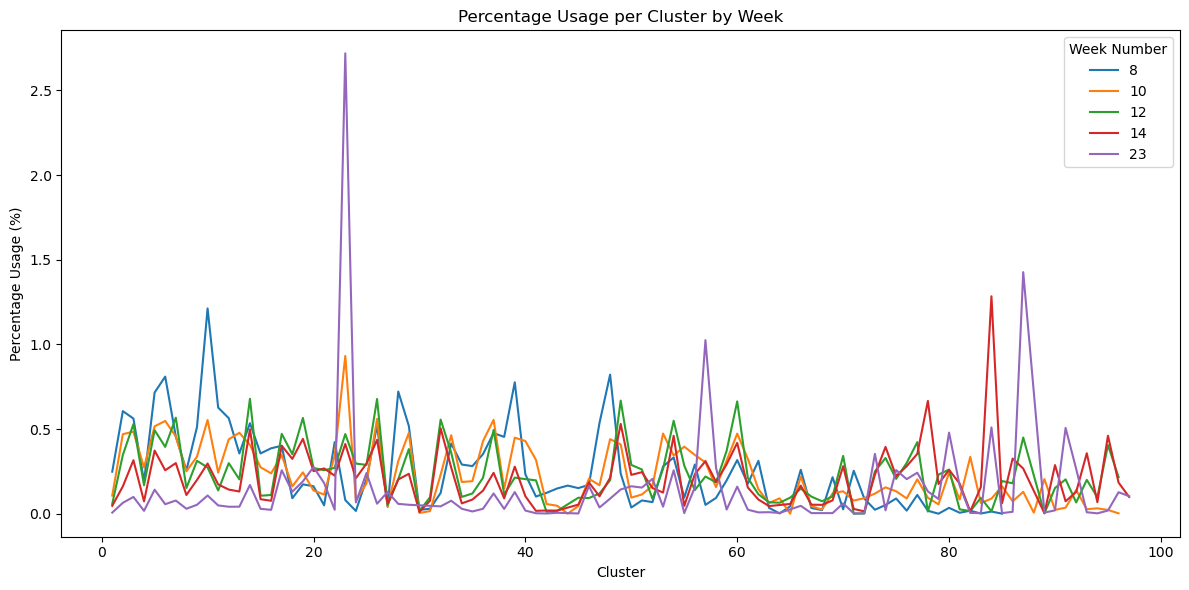

In [26]:
grouped_bout_duration = bout_duration_df.groupby(['ClusterIdx', 'Week_Number'], as_index=False)['duration'].sum()
total_duration = grouped_bout_duration['duration'].sum()
grouped_bout_duration['percentage_usage'] = grouped_bout_duration['duration'] / total_duration * 100

# Cluster Usage (Bout Duration) Percentage
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=grouped_bout_duration,
    x="ClusterIdx",
    y="percentage_usage",
    hue="Week_Number",
    palette="tab10"
)

plt.title("Percentage Usage per Cluster by Week")
plt.xlabel("Cluster")
plt.ylabel("Percentage Usage (%)")
plt.legend(title="Week Number")
plt.tight_layout()
plt.show()

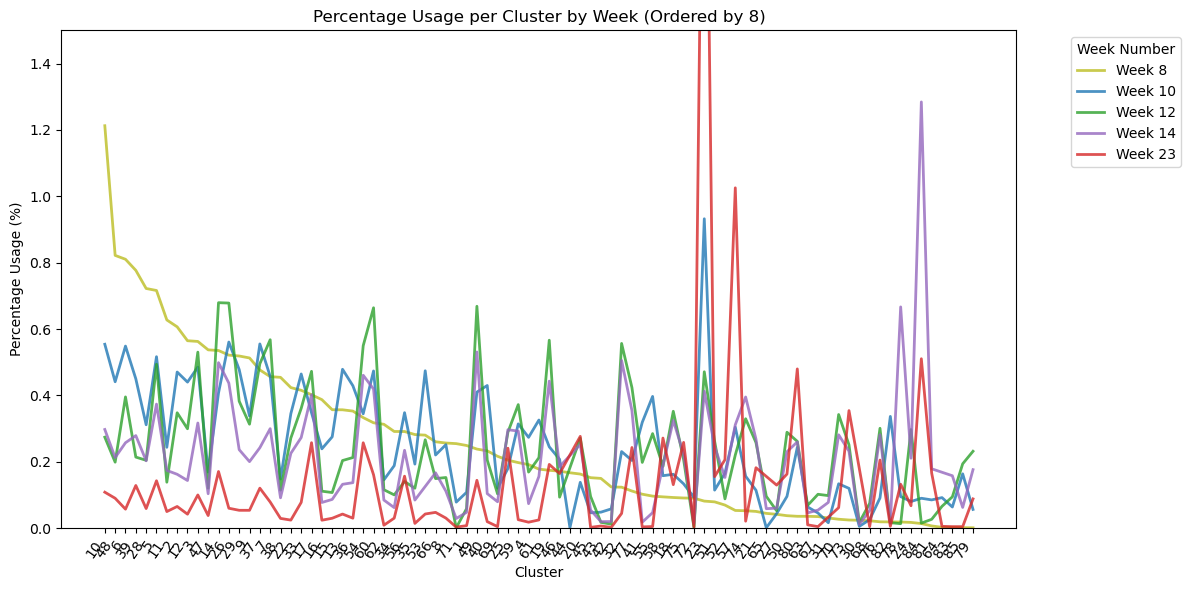

In [ ]:
# Ordering clusters by Week 8 cluster usage
# CHANGE - order by stage 1 
week8_order = grouped_bout_duration[grouped_bout_duration['Week_Number'] == 8]
week8_order = week8_order.sort_values('percentage_usage', ascending=False)['ClusterIdx']

grouped_bout_duration['ClusterIdx'] = pd.Categorical(
    grouped_bout_duration['ClusterIdx'],
    categories=week8_order,
    ordered=True
)

grouped_bout_duration.dropna(inplace=True)
grouped_bout_duration

# Plotting Percentage usage per cluster by week (ordered by 8)
plt.figure(figsize=(12, 6))

for week, group_data in grouped_bout_duration.groupby('Week_Number'):
    group_sorted = group_data.sort_values('ClusterIdx')
    
    x_vals = group_sorted['ClusterIdx'].cat.codes
    
    plt.plot(
        x_vals,
        group_sorted['percentage_usage'],
        label=f"Week {week}",
        linestyle='-',
        linewidth=2,
        alpha=0.8,
        color=plt.cm.tab10(week % 10)
    )

plt.ylim(0, 1.5)

plt.xticks(
    ticks=range(len(grouped_bout_duration['ClusterIdx'].cat.categories)),
    labels=grouped_bout_duration['ClusterIdx'].cat.categories,
    rotation=55, ha='right'
)

plt.title("Percentage Usage per Cluster by Week (Ordered by 8)")
plt.xlabel("Cluster")
plt.ylabel("Percentage Usage (%)")
plt.legend(title="Week Number", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


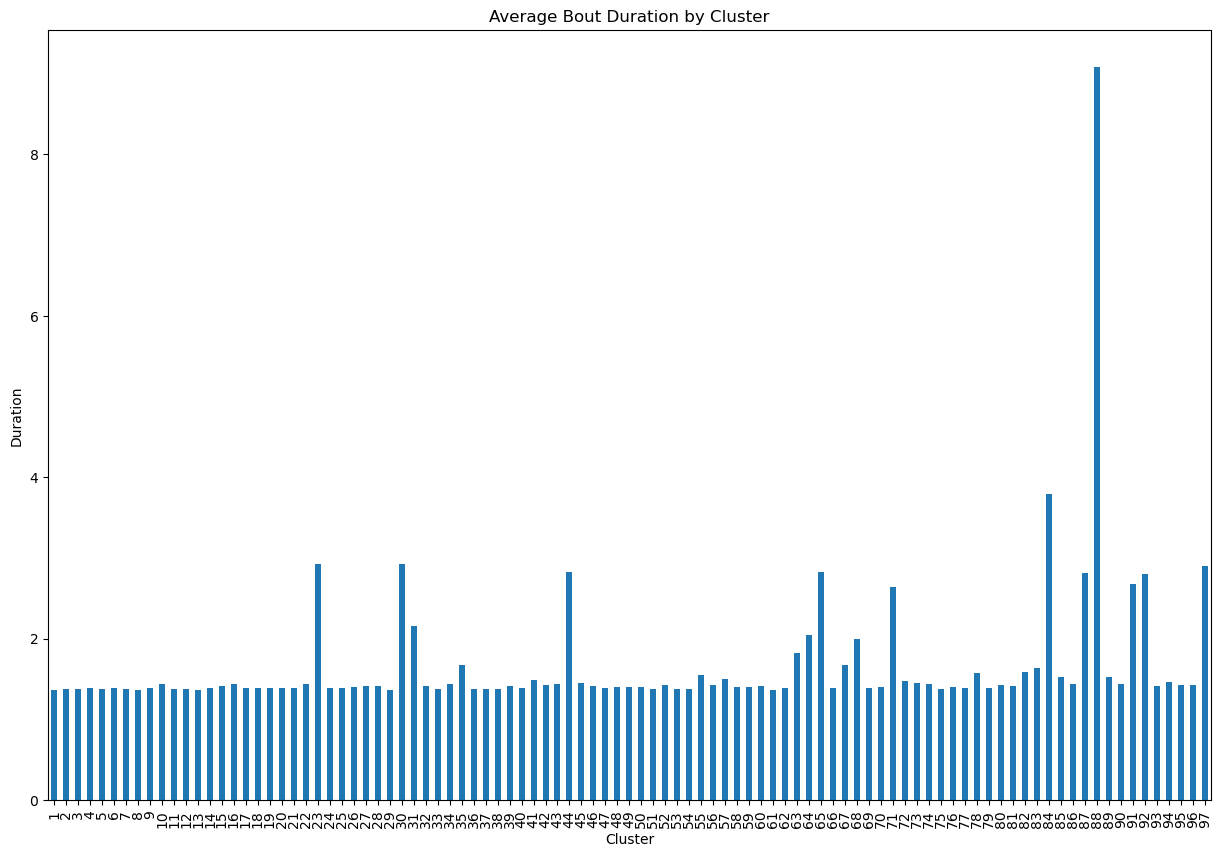

In [28]:
avg_bout_duration_df = bout_duration_df.groupby("ClusterIdx")["duration"].mean()
ax = avg_bout_duration_df.plot(kind="bar", title="Average Bout Duration by Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Duration")

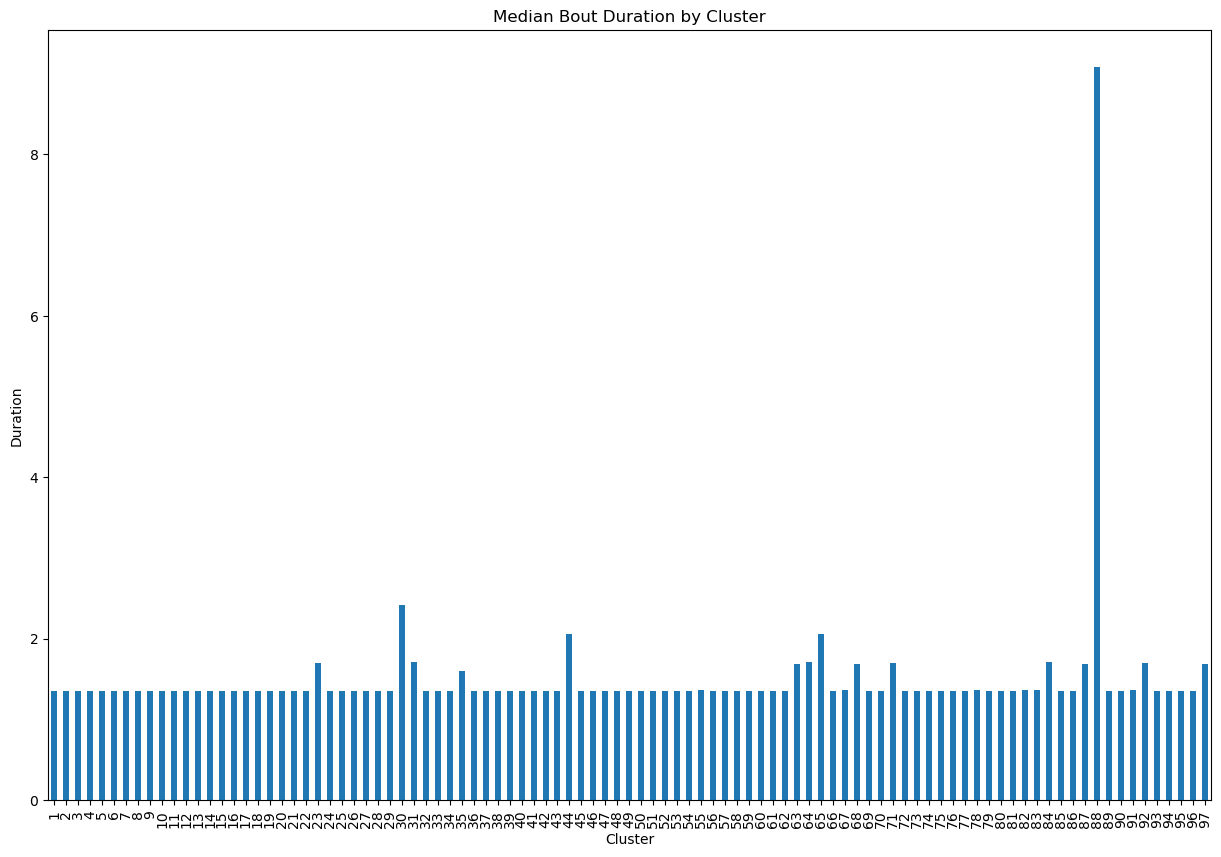

In [29]:
med_bout_duration_df = bout_duration_df.groupby("ClusterIdx")["duration"].median()
ax = med_bout_duration_df.plot(kind="bar", title="Median Bout Duration by Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Duration")

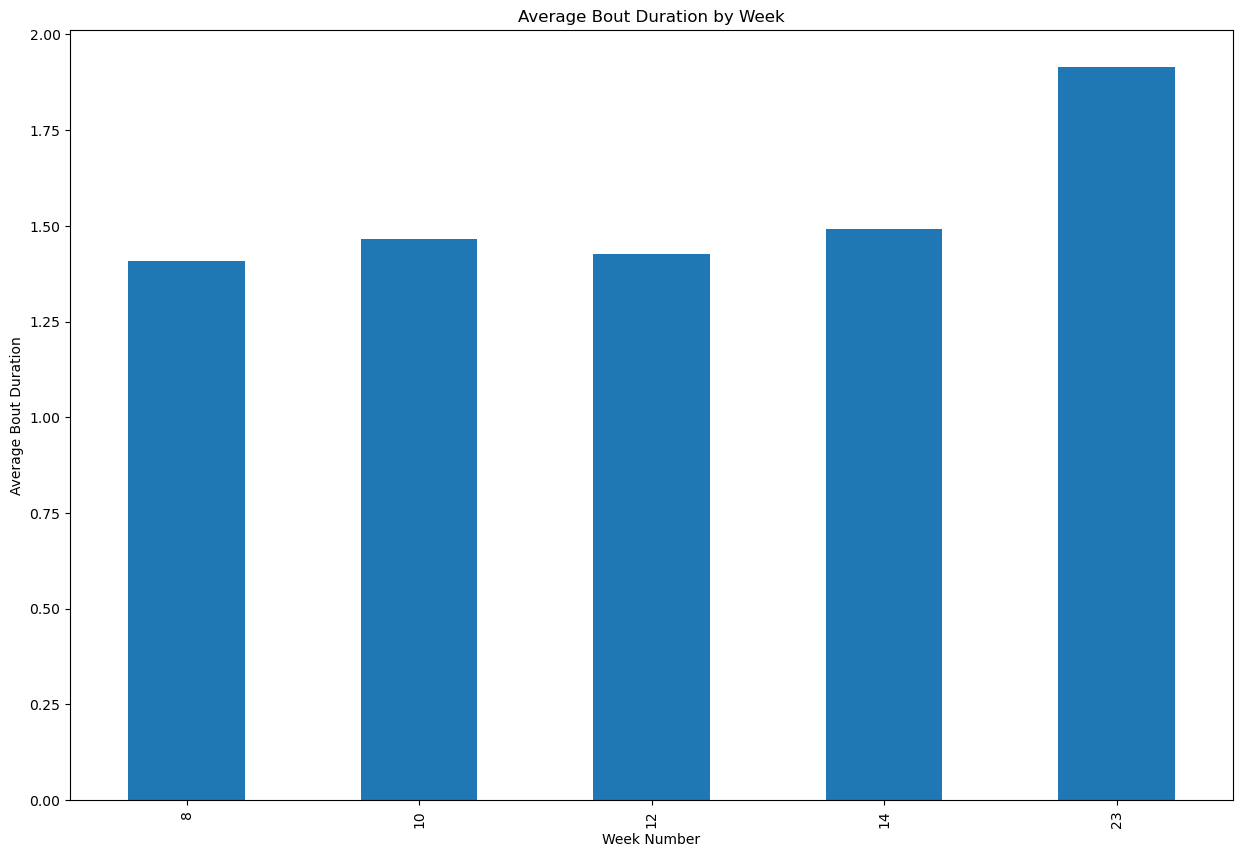

In [30]:
avg_bout_duration_by_week = bout_duration_df.groupby("Week_Number")["duration"].mean()

ax = avg_bout_duration_by_week.plot(
    kind="bar",
    title="Average Bout Duration by Week",
    figsize=(15, 10),
    xlabel="Week Number",
    ylabel="Average Bout Duration"
)

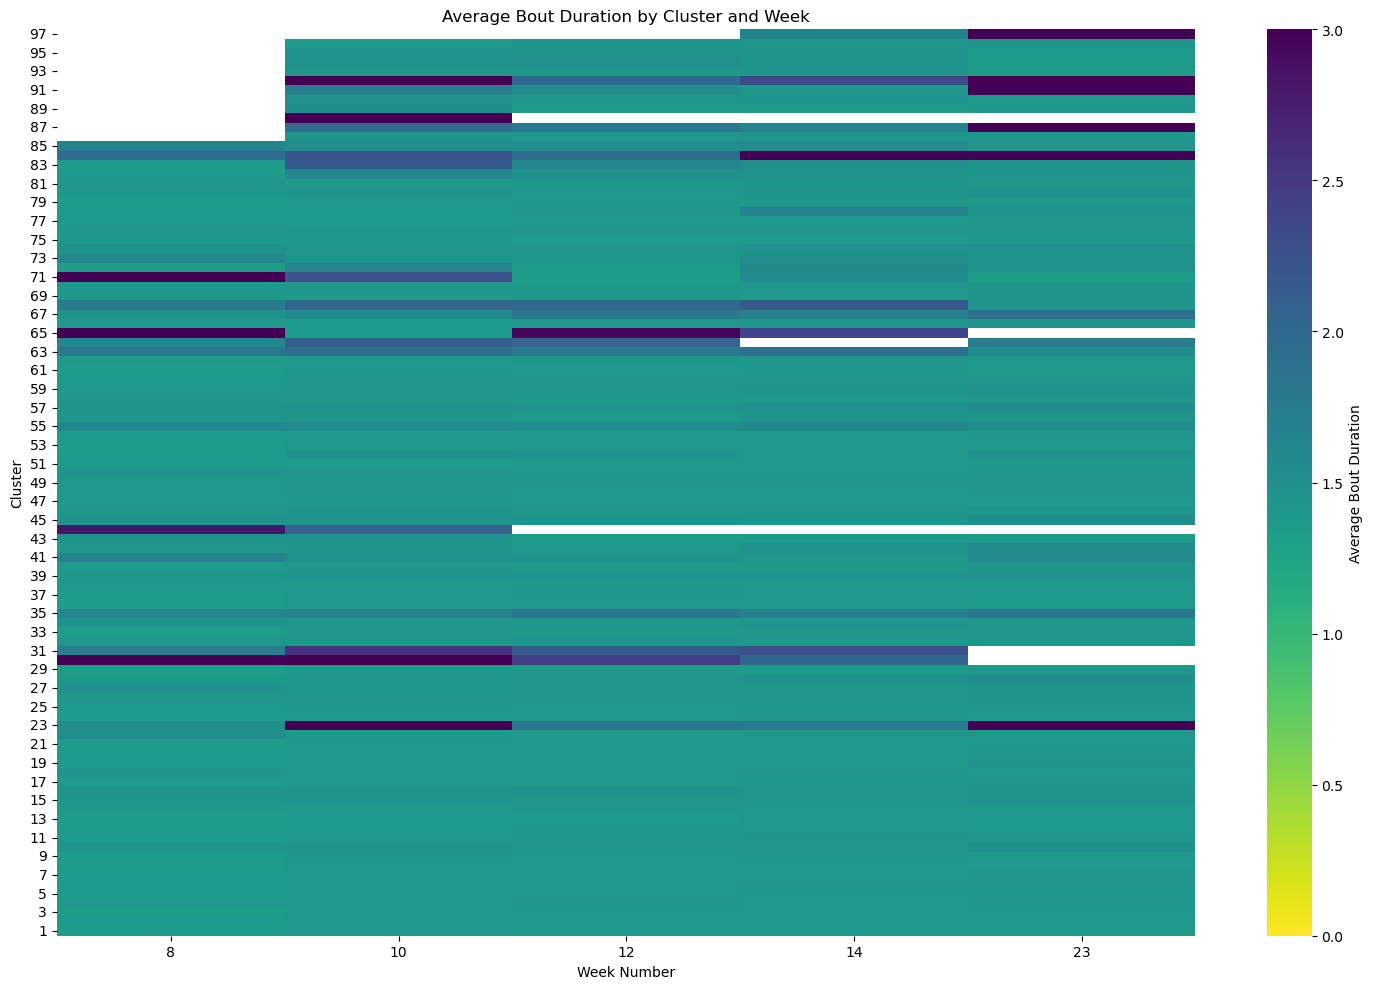

In [31]:
pivot_df = bout_duration_df.groupby(['ClusterIdx', 'Week_Number'])['duration'].mean().unstack()

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',
    vmin=0, vmax=3,
    cbar_kws={'label': 'Average Bout Duration'}
)

ax.invert_yaxis()

plt.title('Average Bout Duration by Cluster and Week')
plt.xlabel('Week Number')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# bout_duration_df.to_csv("bout_duration_df_filtered_mp.csv", index=False, header=True, encoding='utf-8')

In [ ]:
## RECURRENCE INTERVAL
# How much time it takes for clusters to reappear

In [32]:
# Recurrence Time Calculation
recurrence_time_df = bout_duration_df.sort_values(by=['ClusterIdx', 'start_timestamp']).copy()
recurrence_time_df['recurrence_time'] = recurrence_time_df.groupby('ClusterIdx')['start_timestamp'].diff()

recurrence_time_df_filtered = recurrence_time_df.dropna(subset=['recurrence_time'])

In [35]:
# grouped_recurrence_interval = recurrence_time_df_filtered.groupby(['ClusterIdx', 'Week_Number'], as_index=False)['recurrence_time'].sum()
# total_recurrence_time = grouped_recurrence_interval['recurrence_time'].sum()
# grouped_recurrence_interval['percentage_usage'] = grouped_recurrence_interval['recurrence_time'] / total_recurrence_time * 100

# # Cluster Usage (Bout Duration) Percentage
# plt.figure(figsize=(12, 6))
# sns.lineplot(
#     data=grouped_recurrence_interval,
#     x="ClusterIdx",
#     y="percentage_usage",
#     hue="Week_Number",
#     palette="tab10"
# )

# plt.title("Percentage Usage per Cluster by Week")
# plt.xlabel("Cluster")
# plt.ylabel("Percentage Usage (%)")
# plt.legend(title="Week Number")
# plt.tight_layout()
# plt.show()

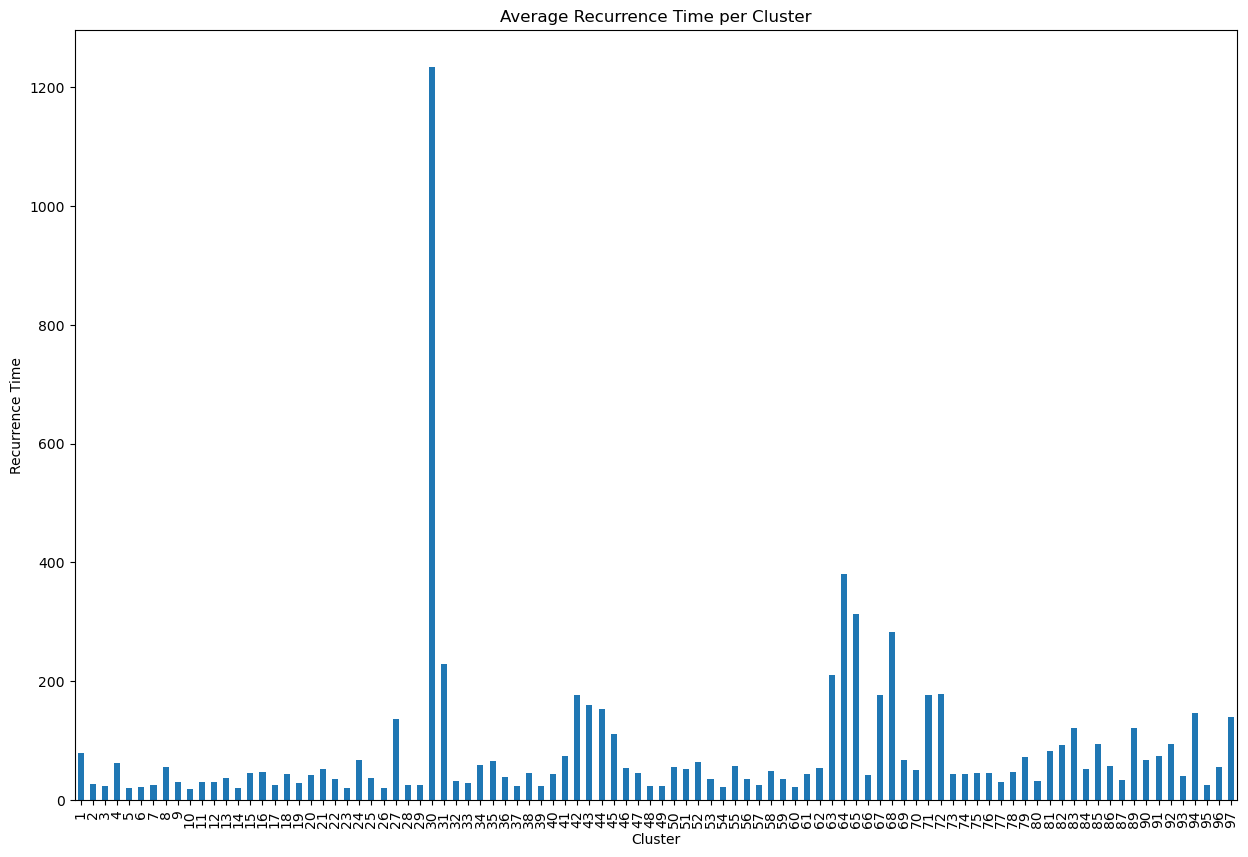

In [36]:
# Mean Recurrence Time Graph
avg_recurrence_time = recurrence_time_df_filtered.groupby("ClusterIdx")["recurrence_time"].mean()
ax = avg_recurrence_time.plot(kind="bar", title="Average Recurrence Time per Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Recurrence Time")

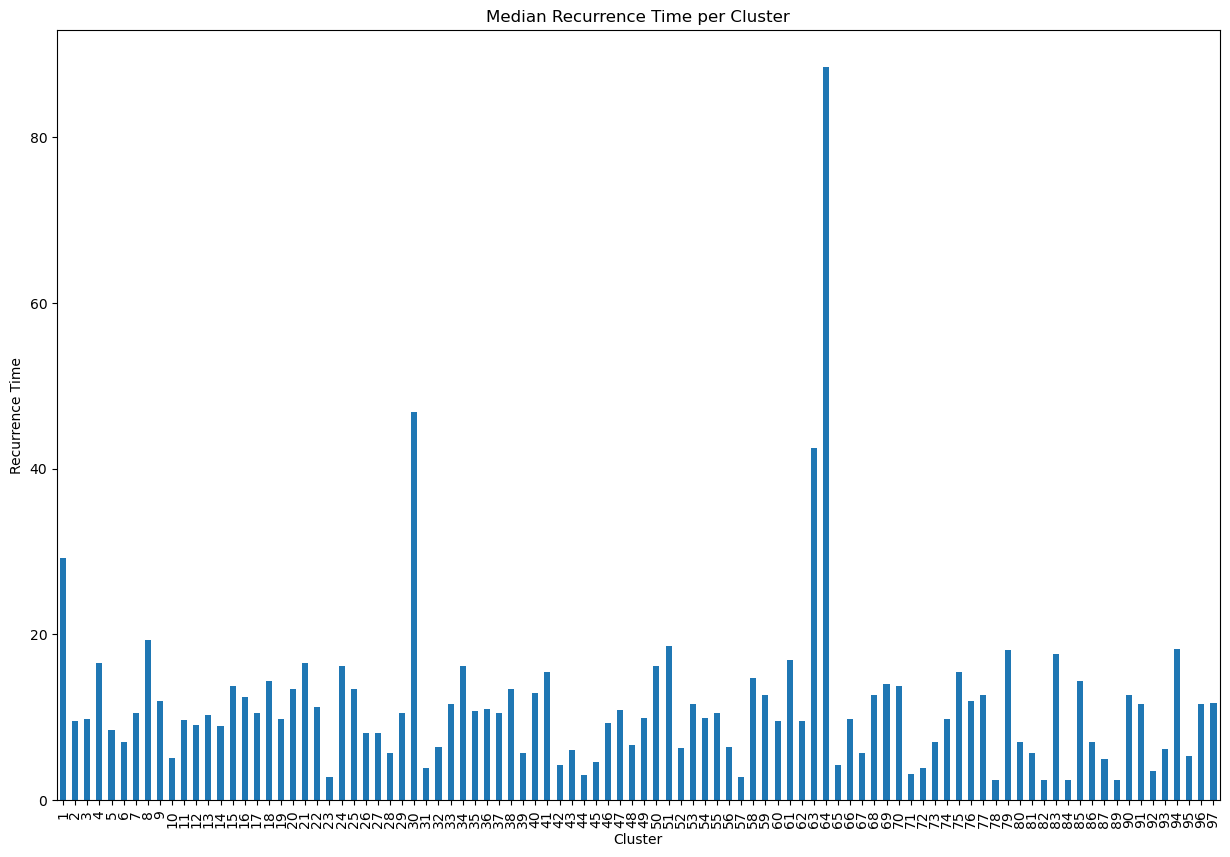

In [37]:
# Median Recurrence Time Graph
med_recurrence_time = recurrence_time_df_filtered.groupby("ClusterIdx")["recurrence_time"].median()
ax = med_recurrence_time.plot(kind="bar", title="Median Recurrence Time per Cluster", figsize=(15, 10), xlabel = "Cluster", ylabel = "Recurrence Time")

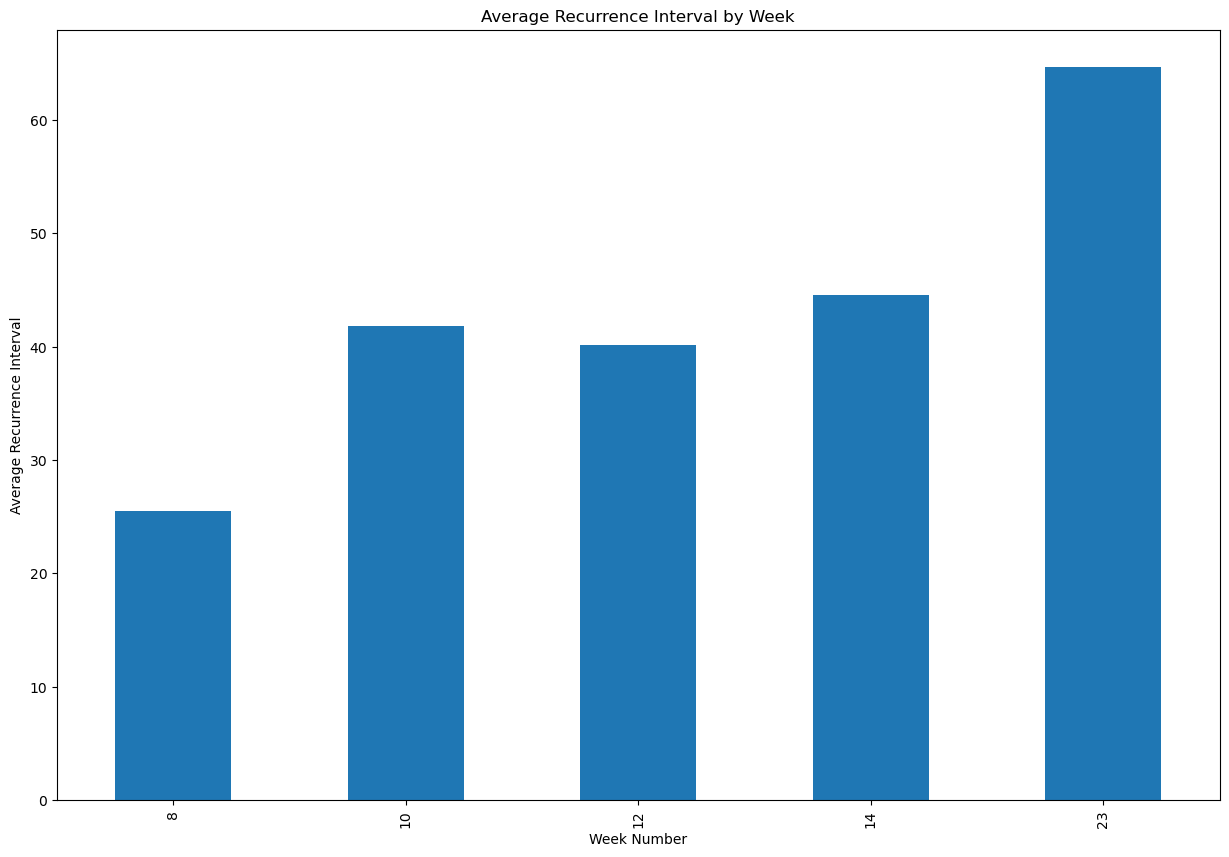

In [38]:
avg_recurrence_duration_by_week = recurrence_time_df_filtered.groupby("Week_Number")["recurrence_time"].mean()

ax = avg_recurrence_duration_by_week.plot(
    kind="bar",
    title="Average Recurrence Interval by Week",
    figsize=(15, 10),
    xlabel="Week Number",
    ylabel="Average Recurrence Interval"
)

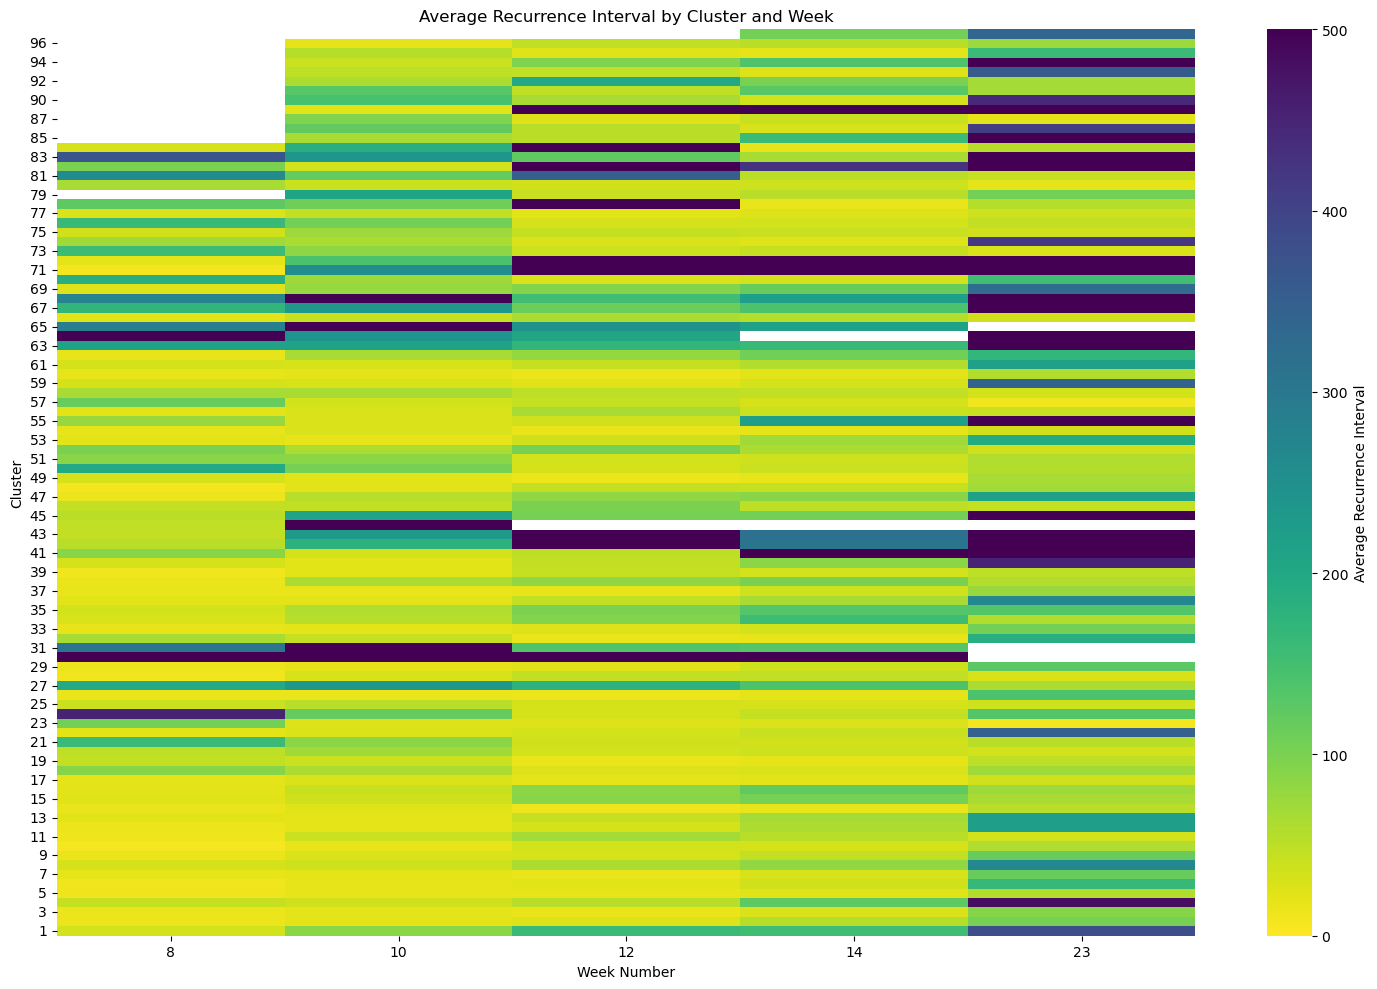

In [39]:
pivot_df = recurrence_time_df_filtered.groupby(['ClusterIdx', 'Week_Number'])['recurrence_time'].mean().unstack()

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    pivot_df,
    cmap='viridis_r',
    vmin=0, vmax=500,
    cbar_kws={'label': 'Average Recurrence Interval'}
)
ax.invert_yaxis()

plt.title('Average Recurrence Interval by Cluster and Week')
plt.xlabel('Week Number')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# recurrence_time_df_filtered.to_csv("recurrence_time_df_filtered_mp.csv", index=False, header=True, encoding='utf-8')